# Lesson 03b: Tensor Products in e3nn

**What you will learn**

- How e3nn generalizes the Clebsch–Gordan tensor product of Lesson 03a into a **learnable layer**: paths + per-path **weights** ($x \otimes_w y$).
- The anatomy of `o3.TensorProduct`: instructions, connection modes (`uvw`, `uvu`, ...), path weights. Also, how to reproduce the output of `o3.TensorProduct` with a bare `einsum`.
- The convenience subclasses `o3.FullyConnectedTensorProduct`, `o3.FullTensorProduct`, `o3.ElementwiseTensorProduct`, and how to **count their weights**.
- Why a plain `nn.Linear` on raw irrep components **breaks equivariance** and why the "mix same-irrep channels only" special case does not.

**Prerequisites:**

- Lesson 02a: `o3.Irreps`
- Lesson 03a: Clebsch–Gordan decomposition, paths, Schur's lemma

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable

import torch
import matplotlib.pyplot as plt
from e3nn import o3

from course_utils.equivariance import assert_equivariant, equivariance_error

torch.set_default_dtype(torch.float64)   # Equivariance checks need double precision
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, device = {device}")

torch 2.7.1+cu126, device = cuda


## From CG paths to a learnable layer

Lesson 03a ended with Schur's lemma: **every equivariant bilinear map is a weighted sum of Clebsch–Gordan paths.** e3nn turns that theorem into an engineering principle: a **weighted tensor product** $x \otimes_w y$ whose free parameters are exactly one weight per path (or per channel combination within a path). This is the learnable layer of equivariant networks: in Tensor Field Networks, the convolution is a CG product of features with filters, and NequIP/MACE (Part IV) are built around the same weighted product.

Let $x = (\vec x_1, \vec x_2)$ of type `1o + 1o` and $y = (y_1, \vec y_2)$ of type `0e + 1o`. One can build an output of type `0e + 1o` as shown below

$$ \begin{equation}(x, y) \mapsto z = \begin{pmatrix}
   w_1\, \vec x_1 \cdot \vec y_2 + w_2\, \vec x_2 \cdot \vec y_2 \\
w_3\, \vec x_1\, y_1 + w_4\, \vec x_2\, y_1 \end{pmatrix}  
\end{equation} $$

Four paths, four weights $w_1, \dots, w_4$: each path an allowed CG coupling ($1 \otimes 1 \to 0$ dot products and $1 \otimes 0 \to 1$ scalar–vector products). In e3nn:

In [2]:
# Creating a Fully Connected Tensor Product
tp = o3.FullyConnectedTensorProduct(
    irreps_in1="1o + 1o",       # x = (x1, x2), two vectors
    irreps_in2="0e + 1o",       # y = (y1, y2), a scalar and a vector
    irreps_out="0e + 1o",       # z = (z1, z2), a scalar and a vector
)

# Note: 4 paths | 4 weights, exactly w1..w4 of Eq. (1) in the notebook
print(tp)
print(f"Parameters: {sum(p.numel() for p in tp.parameters())}")

# Batch of 16 samples, each sample has 2 vectors or a scalar and a vector
x = o3.Irreps("1o + 1o").randn(16, -1)
y = o3.Irreps("0e + 1o").randn(16, -1)

# (16, 4): one 0e + one 1o
print("Output shape:", tuple(tp(x, y).shape))

FullyConnectedTensorProduct(2x1o x 1x0e+1x1o -> 1x0e+1x1o | 4 paths | 4 weights)
Parameters: 4
Output shape: (16, 4)


### `tp.instructions`: the paths, spelled out

A `TensorProduct` is fully specified by its input/output `Irreps` plus a list of **instructions**. Each instruction is one path:

| field | meaning |
|---|---|
| `i_in1, i_in2, i_out` | which entry of `irreps_in1` / `irreps_in2` / `irreps_out` the path connects (indices as irreps lists which must satisfy the selection rules, Eq. 5 of 03a) |
| `connection_mode` | how the *channels* (multiplicities) $u, v, w$ of the three entries are wired |
| `has_weight` | whether the path carries learnable weights |
| `path_weight` | a fixed normalization constant (not learned) chosen so that each path contributes a unit variance |
| `path_shape` | the shape of this path's weight block |

In [3]:
# Print the details of each path in the tensor product
for ins in tp.instructions:
    ir1, ir2, ir3 = tp.irreps_in1[ins.i_in1].ir, tp.irreps_in2[ins.i_in2].ir, tp.irreps_out[ins.i_out].ir
    print(f"{ir1} (x) {ir2} -> {ir3}   {ins}")

1o (x) 0e -> 1o   Instruction(i_in1=0, i_in2=0, i_out=1, connection_mode='uvw', has_weight=True, path_weight=1.224744871391589, path_shape=(1, 1, 1))
1o (x) 1o -> 0e   Instruction(i_in1=0, i_in2=1, i_out=0, connection_mode='uvw', has_weight=True, path_weight=0.7071067811865476, path_shape=(1, 1, 1))
1o (x) 0e -> 1o   Instruction(i_in1=1, i_in2=0, i_out=1, connection_mode='uvw', has_weight=True, path_weight=1.224744871391589, path_shape=(1, 1, 1))
1o (x) 1o -> 0e   Instruction(i_in1=1, i_in2=1, i_out=0, connection_mode='uvw', has_weight=True, path_weight=0.7071067811865476, path_shape=(1, 1, 1))


e3nn offers a convenience method to visualize the paths in a diagram

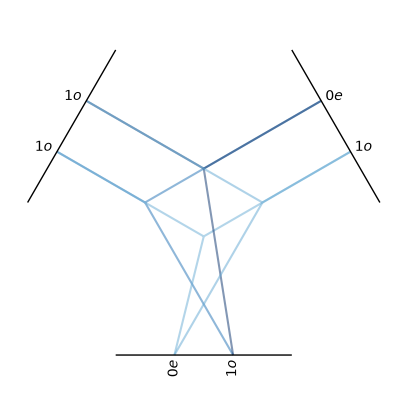

In [4]:
# e3nn's built-in path diagram
fig, ax = tp.visualize()
fig.set_size_inches(5, 5)
plt.show()

The diagram reads as the top-left the entries are from input 1, top-right from input 2, and the bottom from the outputs. Each curve through the center is one path/instruction.

## Connection modes and the path equations

Within one path, the entries have **multiplicities** (channels): $u = 1, \dots, m_1$ for input 1, $v = 1, \dots, m_2$ for input 2, $w$ for the output. The `connection_mode` says how they are wired. There are two main workhorses:

**Fully connected** (`uvw`): Every channel pair $(u, v)$ feeds every output channel $w$, with an independent weight $w_{uvw}$. So, the resulting path has $m_1 m_2 m_3$ weights:

$$ (\text{value of path})_{wk} = \frac{1}{\sqrt{m_1 m_2}} \sum_{u=1}^{m_1} \sum_{v=1}^{m_2} \sum_{i=1}^{2l_1+1} \sum_{j=1}^{2l_2+1} w_{uvw}\, C_{ijk}\, (\mathrm{in1})_{ui}\, (\mathrm{in2})_{vj}  .$$

**Input-1-preserving** (`uvu`): The output inherits the channel index $u$ of input 1 ($m_3 = m_1$), and only $(u, v)$ carries a weight (the $m_1 m_2$ weights):

$$ (\text{value of path})_{uk} = \frac{1}{\sqrt{m_2}} \sum_{v=1}^{m_2} \sum_{i=1}^{2l_1+1} \sum_{j=1}^{2l_2+1} w_{uv}\, C_{ijk}\, (\mathrm{in1})_{ui}\, (\mathrm{in2})_{vj}   $$

Here, $C_{ijk}$ denotes the CG coefficient, `o3.wigner_3j(l1, l2, l3)` and the prefactors, $1/\sqrt{m_1 m_2}$ and $1/\sqrt{m_2}$, keep the output variance at 1. When several paths land on the same output, the equations are additionally scaled by $1/\sqrt{\#\text{paths}}$. All of these constants are folded into the `path_weight` parameter of the tensor product instructions. For details on other modes, (e.g., `uuu`, `uvuv`, ...) see the e3nn documentation.

Let us build `o3.TensorProduct` from scratch using a single explicit instruction and reproduce its output only with `wigner_3j` and `einsum` to demistify its hidden complexities.

> **Terminology note:** We call each *instruction* a path; e3nn's printed `repr`
> instead counts the channel-resolved $(u, v, w)$ combinations, so one `uvw`
> instruction with $m_1 m_2 m_3 = 6$ weights prints as "6 paths". It is the
> object but with a finer-grained count.

First, we create a tensor product with one `uvw` instruction, connecting the first entry of input 1, the first entry of input 2, and the first entry of the output. The instruction carries weights, so the output is a learnable linear combination of the CG paths. We will check that the output of the tensor product is exactly the same as the explicit `einsum` of the CG coefficients with the input features and the weights.

In [5]:
# One 'uvw' path:  2x1o  (x)  1x1o  ->  3x0e 
# (a learnable, multi-channel dot product)
# (i_in1, i_in2, i_out, mode, has_weight)
tp_uvw = o3.TensorProduct(
    "2x1o", "1x1o", "3x0e",
    instructions=[(0, 0, 0, "uvw", True)],   
)
print(tp_uvw, "| weights:", tp_uvw.weight_numel, "= m1*m2*m3 = 2*1*3")

# 16 samples, 2 channels x 3 components
x = torch.randn(16, 6)
y = torch.randn(16, 3)

# Check the instructions of the tensor product
ins = tp_uvw.instructions[0]
print(f"Instruction: {ins} | weight shape: {tp_uvw.weight.shape} | path shape: {ins.path_shape}")

# (m1, m2, m3) = (2, 1, 3)
w = tp_uvw.weight.reshape(ins.path_shape)

# C.shape = (2l1+1=3, 2l2+1=3, 2l3+1=1)
C = o3.wigner_3j(1, 1, 0)

# Eq. (2), with the normalization constants folded into ins.path_weight:
manual = ins.path_weight * torch.einsum(
    "uvw,ijk,bui,bvj->bwk", w, C, x.reshape(16, 2, 3), y.reshape(16, 1, 3)
).reshape(16, 3)
print("einsum reproduces o3.TensorProduct ('uvw'):", torch.allclose(tp_uvw(x, y), manual))

TensorProduct(2x1o x 1x1o -> 3x0e | 6 paths | 6 weights) | weights: 6 = m1*m2*m3 = 2*1*3
Instruction: Instruction(i_in1=0, i_in2=0, i_out=0, connection_mode='uvw', has_weight=True, path_weight=0.7071067811865476, path_shape=(2, 1, 3)) | weight shape: torch.Size([6]) | path shape: (2, 1, 3)
einsum reproduces o3.TensorProduct ('uvw'): True


In [6]:
# same inputs, one 'uvu' path:  2x1o  (x)  1x1o  ->  2x1e
# (channel-wise cross products)
# (i_in1, i_in2, i_out, mode, has_weight)
tp_uvu = o3.TensorProduct(
    "2x1o", "1x1o", "2x1e",
    instructions=[(0, 0, 0, "uvu", True)],
)
print(tp_uvu, "| weights:", tp_uvu.weight_numel, "= m1*m2 = 2*1")

# Check the instructions of the tensor product
ins = tp_uvu.instructions[0]
print(f"Instruction: {ins} | weight shape: {tp_uvu.weight.shape} | path shape: {ins.path_shape}")

# (m1, m2) = (2, 1)
w = tp_uvu.weight.reshape(ins.path_shape)

# C.shape = (2l1+1=3, 2l2+1=3, 2l3+1=3)
C = o3.wigner_3j(1, 1, 1)

# Eq. (3): output keeps channel u
manual = ins.path_weight * torch.einsum(
    "uv,ijk,bui,bvj->buk", w, C, x.reshape(16, 2, 3), y.reshape(16, 1, 3)
).reshape(16, 6)
print("einsum reproduces o3.TensorProduct ('uvu'):", torch.allclose(tp_uvu(x, y), manual))

TensorProduct(2x1o x 1x1o -> 2x1e | 2 paths | 2 weights) | weights: 2 = m1*m2 = 2*1
Instruction: Instruction(i_in1=0, i_in2=0, i_out=0, connection_mode='uvu', has_weight=True, path_weight=1.7320508075688772, path_shape=(2, 1)) | weight shape: torch.Size([2]) | path shape: (2, 1)
einsum reproduces o3.TensorProduct ('uvu'): True


Both layers above are indeed *one einsum with the CG tensor*: everything else is bookkeeping. The `uvw`/`uvu` distinction matters at scale: `uvw` costs $m_1 m_2 m_3$ weights per path (great capacity, expensive). On the other hand, `uvu` costs $m_1 m_2$ (this is what NequIP uses in its convolutions, where input 2 is the spherical-harmonic edge embedding. We will discuss this topic in Lesson 08).

## The convenience subclasses

### `o3.FullyConnectedTensorProduct`

This function creates **every** selection-rule-allowed path with mode `uvw`. Its weight count is explicitly given by the formula

$$ \#\text{weights} \;=\; \sum_{\substack{\text{allowed}\ (l_1, p_1),\, (l_2, p_2),\, (l_3, p_3)}} m_1\, m_2\, m_3 . $$

In [7]:
# A typical input feature layout
irreps1  = o3.Irreps("8x0e + 4x1o + 2x2e")

# E.g., spherical harmonics of an edge, l <= 2
irreps2  = o3.Irreps("1x0e + 1x1o + 1x2e")

# A typical output feature layout
irreps3  = o3.Irreps("8x0e + 4x1o + 2x2e")

# Fully connected tensor product: creates every selection-rule-allowed path with mode 'uvw'
fctp = o3.FullyConnectedTensorProduct(irreps1, irreps2, irreps3)
print(fctp)
print(f"parameters: {sum(p.numel() for p in fctp.parameters())}")

# Check the weight-count formula by explicit enumeration:
# (Selection rules)
n = sum(m1 * m2 * m3
        for m1, ir1 in irreps1 for m2, ir2 in irreps2 for m3, ir3 in irreps3
        if ir3 in ir1 * ir2)                    
print("formula gives:", n, "| e3nn says:", fctp.weight_numel)

FullyConnectedTensorProduct(8x0e+4x1o+2x2e x 1x0e+1x1o+1x2e -> 8x0e+4x1o+2x2e | 216 paths | 216 weights)
parameters: 216
formula gives: 216 | e3nn says: 216


In [8]:
# Cquivariance check (course policy): concatenate both inputs into one feature vector
def fctp_as_single_input(z):
    return fctp(z[:, : irreps1.dim], z[:, irreps1.dim :])

assert_equivariant(fctp_as_single_input, irreps_in=irreps1 + irreps2, irreps_out=irreps3)

equivariant!  (max error 3.242e-14 over random O(3) elements)


3.241851231905457e-14

### `o3.FullTensorProduct`: The mathematician's $\otimes$

Here, there are no weights or choices: *all* output irreps allowed by the selection rules are computed and kept. This is exactly the CG contraction we hand-built in Lesson 03a (e3nn scales each block by $\sqrt{2 l_3 + 1}$ so that every output component has unit variance: the `component` normalization).

In [9]:
# 1o (x) 1o -> 0e + 1e + 2e, 0 weights
ftp = o3.FullTensorProduct("1o", "1o")
print(ftp)

# Create random input features for 16 samples, each with 3 components (1o)
xv, yv = torch.randn(16, 3), torch.randn(16, 3)

# Compute the manual CG contraction
manual = torch.cat(
    [(2 * l + 1) ** 0.5 * torch.einsum("ijk,bi,bj->bk", o3.wigner_3j(1, 1, l), xv, yv)
     for l in (0, 1, 2)], dim=-1)
print("FullTensorProduct == sqrt(2l3+1) * CG contraction of 03a:",
      torch.allclose(ftp(xv, yv), manual))

FullTensorProduct(1x1o x 1x1o -> 1x0e+1x1e+1x2e | 3 paths | 0 weights)
FullTensorProduct == sqrt(2l3+1) * CG contraction of 03a: True


### `o3.ElementwiseTensorProduct`: Channel-aligned paths

In order to use this function, both inputs must have the **same total multiplicity**: channel $u$ of input 1 is multiplied with channel $u$ of input 2 (no mixing, no weights). This is the workhorse of **gating** (which we will discuss in Lesson 04) and of TFN-style products of features with per-channel filters.

In [10]:
# Channels are aligned in order: 0e*1o -> 1o,  0e*0e -> 0e,  1o*0e -> 1o
etp = o3.ElementwiseTensorProduct("2x0e + 1x1o", "1x1o + 2x0e")
print(etp)

# Define a function that wraps the ElementwiseTensorProduct to take a single input
def etp_as_single_input(z):
    return etp(z[:, : etp.irreps_in1.dim], z[:, etp.irreps_in1.dim :])

# Cquivariance check (course policy): concatenate both inputs into one feature vector
assert_equivariant(etp_as_single_input,
                   irreps_in=etp.irreps_in1 + etp.irreps_in2, irreps_out=etp.irreps_out)

ElementwiseTensorProduct(2x0e+1x1o x 1x1o+2x0e -> 1x1o+1x0e+1x1o | 3 paths | 0 weights)
equivariant!  (max error 8.882e-16 over random O(3) elements)


8.881784197001252e-16

**The convinience functions at a glance:**

| class | paths | weights | typical use |
|---|---|---|---|
| `o3.TensorProduct` | you choose | you choose (`uvw`, `uvu`, …) | full control (NequIP, MACE internals) |
| `o3.FullyConnectedTensorProduct` | all allowed, `uvw` | $\sum m_1 m_2 m_3$ | learnable mixing layer |
| `o3.FullTensorProduct` | all allowed | none | the mathematical $\otimes$ |
| `o3.ElementwiseTensorProduct` | channel-aligned | none | gates, feature $\times$ filter |

## What goes wrong without the machinery: a broken "linear layer"

Why insist on paths and CG coefficients even for something as simple as a linear layer? Because a dense matrix acting on the raw components of, say, a `0e + 1o` feature freely mixes the scalar with individual vector components and a vector component alone is **not** an equivariant object. Let us demonstrate this with a simple example:

In [11]:
# 4 numbers: [s, vy, vz, vx]
irreps = o3.Irreps("0e + 1o")

# A plain dense 4x4 matrix
naive = torch.nn.Linear(irreps.dim, irreps.dim, bias=False)

# Check the equivariance error of the naive dense layer
err = equivariance_error(naive, irreps_in=irreps, irreps_out=irreps)
print(f"naive dense layer: max equivariance error = {err:.3f}   (should be ~1e-15 if equivariant)")

# Check the equivariance of the naive dense layer using assert_equivariant
try:
    assert_equivariant(naive, irreps_in=irreps, irreps_out=irreps)
except AssertionError as e:
    print("assert_equivariant:", e)

naive dense layer: max equivariance error = 2.954   (should be ~1e-15 if equivariant)
assert_equivariant: equivariance violated: max error 2.423e+00 >= tol 1.0e-09


The layer output changes depending on the orientation of the input. Any network containing such a layer loses every equivariance guarantees discussed in Lesson 01.

### `o3.Linear`: The equivariant linear layer

Schur's lemma (Lesson 03a, Sec. 6) tells us exactly which linear maps *are* allowed: within each irrep, channels may be mixed by arbitrary matrices $W$ (the same $W$ for all $2l+1$ components $m$) and across different irreps, nothing mixes or interacts. The `o3.Linear(irreps_in, irreps_out)` function implements precisely this, so its weight count is $\sum_{(l,p)} m_{\text{in}}^{(l,p)}\, m_{\text{out}}^{(l,p)}$ over matching irreps. It is the tensor product's "unary" sibling and equivalent to a fully connected tensor product of the input with the constant scalar $1$ (`0e`).

In [12]:
# Define an equivariant linear layer using o3.Linear
lin = o3.Linear("3x0e + 2x1o", "4x0e + 2x1o")

# 3*4 + 2*2 = 16 weights
print(lin)
print(f"parameters: {sum(p.numel() for p in lin.parameters())}")

# Check the equivariance of the o3.Linear layer using assert_equivariant
assert_equivariant(lin, irreps_in="3x0e + 2x1o", irreps_out="4x0e + 2x1o")

Linear(3x0e+2x1o -> 4x0e+2x1o | 16 weights)
parameters: 16
equivariant!  (max error 8.882e-16 over random O(3) elements)


8.881784197001252e-16

Now, let us visualize the outputs of a naive dense layer and an equivariant `o3.Linear` layer for a simple input.

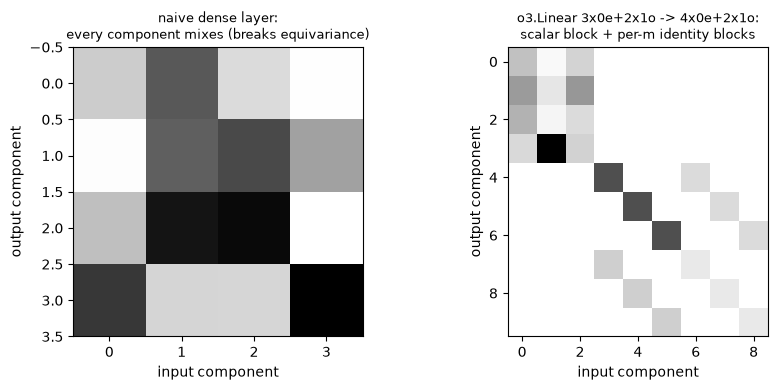

In [13]:
# Visualize which outputs may depend on which inputs: the Jacobian of both layers
# The inputs are 4 numbers for the naive layer and 9 numbers for the o3.Linear layer
J_naive = torch.autograd.functional.jacobian(lambda z: naive(z), torch.randn(4))
J_lin = torch.autograd.functional.jacobian(lambda z: lin(z), torch.randn(9))

# The Jacobian matrices show the sensitivity of the outputs to the inputs.
# Plot the absolute values of the Jacobians to visualize which outputs depend on which inputs
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(J_naive.abs(), cmap="Greys")
axes[0].set_title("naive dense layer:\nevery component mixes (breaks equivariance)", fontsize=9)
axes[1].imshow(J_lin.abs(), cmap="Greys")
axes[1].set_title("o3.Linear 3x0e+2x1o -> 4x0e+2x1o:\nscalar block + per-m identity blocks", fontsize=9)
for ax in axes:
    ax.set_xlabel("input component")
    ax.set_ylabel("output component")
fig.tight_layout()
plt.show()

In the right panel, the top-left $4 \times 3$ block mixes the scalar channels freely, while the vector part consists of $2 \times 2$ channel mixing applied *identically* to each of the three $m$ components (diagonal stripes): Schur's lemma drawn as a picture: **same irrep, same $m$, mix channels only.**

## Summary

In this lesson, we learned that:

- e3nn's `o3.TensorProduct` yields a list of CG **paths** (instructions), each optionally weighted: the complete parametrization of equivariant bilinear maps.
- The **Connection modes** wire the channels: The `uvw` mode demostrates a fully connected contraction with $m_1 m_2 m_3$ weights per path (Eq. 2) vs. `uvu` with $m_1 m_2$ weights whose output keeps the input-1's channels, (Eq. 3). A fixed `path_weight` constant keeps the output variance at 1.
- We reproduced both contraction modes **exactly** with a single `wigner_3j` + `einsum`.
- The e3nn's subclasses: `FullyConnectedTensorProduct` (all paths, learnable), `FullTensorProduct` (all paths, no weights = Lesson 03a's $\otimes$), `ElementwiseTensorProduct` (channel-aligned, no weights: the gate's engine).
- A plain dense layer operating on raw components of features fails the equivariance test with $O(1)$ error. The `o3.Linear` (per-irrep channel mixing) is the equivariant replacement.

**Next:** Lesson 04 gives us the last missing ingredient: the equivariant *nonlinearities* (norm activations and the Gate), and our first full equivariant MLP.

## Exercises

**Exercise 1: count before you run.** Without running it, compute the number of weights of `o3.FullyConnectedTensorProduct("4x0e + 4x1o", "0e + 1o", "4x0e + 4x1o")`. Then check.

<details><summary>Solution</summary>

Allowed $(ir_1, ir_2, ir_3)$ triples and their $m_1 m_2 m_3$:
- $0e{\times}0e{\to}0e$: $4{\cdot}1{\cdot}4 = 16$
- $0e{\times}1o{\to}1o$: 16
- $1o{\times}0e{\to}1o$: 16
- $1o{\times}1o{\to}0e$: 16
- $1o{\times}1o\to 1e, 2e$ are not in the output irreps
- Total **64**

```python
# Prints 64
print(o3.FullyConnectedTensorProduct("4x0e + 4x1o", "0e + 1o", "4x0e + 4x1o").weight_numel)
```
</details>

**Exercise 2: The cross product as a TensorProduct.** Build an unweighted `o3.TensorProduct` mapping `1x1o (x) 1x1o -> 1x1e` with the single instruction `(0, 0, 0, "uuu", False)` (mode `uvw` requires weights; `uuu` works unweighted since all multiplicities are 1 here) and compare its output to `torch.cross`. What is the proportionality constant, and where does it come from? (Remember e3nn's $(y, z, x)$ component order from Lesson 03a.)

<details><summary>Solution</summary>

```python
# The unweighted tensor product computes the cross product up to a constant factor
tp_x = o3.TensorProduct("1o", "1o", "1e", [(0, 0, 0, "uuu", False)])

# Random vectors in R^3
a, b = torch.randn(3), torch.randn(3)

# Compute the tensor product
out = tp_x(a[None], b[None])[0]

# Reorder the components to match torch.cross's (x, y, z) order and compare
cart = [2, 0, 1]
print(out[cart] * 2**0.5, torch.cross(a[cart], b[cart], dim=0))
```

The constant is $\sqrt 2$: the CG contraction gives $(\vec a \times \vec b)/\sqrt 6$ (Lesson 03a) and the `component` normalization multiplies by `path_weight` $= \sqrt{2l_3+1} = \sqrt 3$, so e3nn returns $\sqrt{3/6}\,(\vec a \times \vec b) = (\vec a \times \vec b)/\sqrt 2$. </details>

**Exercise 3: `uvw` vs. `uvu` at NequIP scale.** For a convolution combining features `32x0e + 32x1o + 32x2e` with edge harmonics `0e + 1o + 2e` into `32x0e + 32x1o + 32x2e`, how many weights are there for all-`uvw` paths (`FullyConnectedTensorProduct`) vs. the same paths in `uvu` mode? (For `uvu`, count $m_1 m_2$ per allowed path.)

<details><summary>Solution</summary>

```python
# Create the irreps
i1, i2, i3 = (o3.Irreps("32x0e + 32x1o + 32x2e"), o3.Irreps("0e + 1o + 2e"),
              o3.Irreps("32x0e + 32x1o + 32x2e"))

# Enumerate the allowed paths
paths = [(a, b, c) for a, (m1, ir1) in enumerate(i1) for b, (m2, ir2) in enumerate(i2)
         for c, (m3, ir3) in enumerate(i3) if ir3 in ir1 * ir2]

# Count the weights
# uvw: 11264
print(o3.FullyConnectedTensorProduct(i1, i2, i3).weight_numel)

# uvu: 352
tp_uvu = o3.TensorProduct(i1, i2, i3, [(a, b, c, "uvu", True) for a, b, c in paths])
print(tp_uvu.weight_numel)
```

There are 11 allowed paths. `uvw`: $11 \times 32 \cdot 1 \cdot 32 = 11264$. `uvu`: $11 \times 32 \cdot 1 = 352$: a factor $m_3 = 32$ fewer. This economy is why NequIP-style convolutions use `uvu` and delegate channel mixing to separate `o3.Linear` layers. </details>

## References

- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)
- [Thomas et al., *Tensor Field Networks* arXiv.1802.08219 (2018)](https://arxiv.org/pdf/1802.08219)